In [ ]:
#Name: Aashish Singh , Section: Q , Roll No.: 20

In [ ]:
"""
Problem Statement: 11
Consider a dataset (salary_prediction2.csv) containing multiple input 
features related to employee performance and a target variable Salary. 
Implement a program to perform Multiple Linear Regression and analyze 
the relationship between multiple input features and the target variable. 
Perform the following tasks: 
i. Read the given dataset into a dataframe. 
ii. Split the dataset into training and testing sets in the ratio 70:30, 
60:40, 80:20. 
iii. Train a Multiple Linear Regression model using all input 
features to predict the target variable Salary. 
iv. Determine the coefficients of each input feature and the 
intercept of the best-fit regression model. 
v. Plot appropriate graphs to compare actual vs predicted salary 
values. 
vi. Use the trained model to predict the salary for new data points 
taken as input from the user. 
vii. Evaluate the performance of the model using appropriate 
regression metrics. 
"""

In [2]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
# Creating synthetic employee data
np.random.seed(42)

n = 200

years_experience = np.random.randint(0, 15, n)
education_level = np.random.randint(1, 4, n)
projects_completed = np.random.randint(1, 20, n)
performance_score = np.random.randint(4, 10, n)
working_hours = np.random.randint(35, 55, n)
certifications = np.random.randint(0, 6, n)

# Create salary with realistic relationship
salary = (
    years_experience * 4000 +
    education_level * 8000 +
    projects_completed * 1500 +
    performance_score * 2000 +
    certifications * 3000 +
    working_hours * 200 +
    np.random.randint(-5000, 5000, n)   # noise
)

df = pd.DataFrame({
    "years_experience": years_experience,
    "education_level": education_level,
    "projects_completed": projects_completed,
    "performance_score": performance_score,
    "working_hours_per_week": working_hours,
    "certifications": certifications,
    "salary": salary
})

df.to_csv("salary_prediction2.csv", index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [5]:
# Assume last column is target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Dataset Shape:", df.shape)

Dataset Shape: (200, 7)


In [12]:
# -------------------------------
# Function to train + evaluate
# -------------------------------
def train_and_evaluate(test_ratio):
    print(f"\n--- Train-Test Split {int((1-test_ratio)*100)}:{int(test_ratio*100)} ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    # -------------------------------
    # iv. Coefficients & Intercept
    # -------------------------------
    print("Intercept:", model.intercept_)
    print("Coefficients:")
    for col, coef in zip(X.columns, model.coef_):
        print(f"{col}: {coef}")

    # Predictions
    y_pred = model.predict(X_test)

    # -------------------------------
    # v. Plot Actual vs Predicted
    # -------------------------------
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Salary")
    plt.ylabel("Predicted Salary")
    plt.title(f"Actual vs Predicted ({int((1-test_ratio)*100)}:{int(test_ratio*100)})")
    plt.plot([y.min(), y.max()], [y.min(), y.max()])
    plt.show()

    # -------------------------------
    # vii. Evaluation Metrics
    # -------------------------------
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("MAE:", mae)
    print("MSE:", mse)
    print("R2 Score:", r2)

    return model



--- Train-Test Split 70:30 ---
Intercept: 2754.0130694894033
Coefficients:
years_experience: 3946.521047063059
education_level: 7940.431612948955
projects_completed: 1437.19310999351
performance_score: 1790.2354375045393
working_hours_per_week: 192.17786792322977
certifications: 3106.005991299288


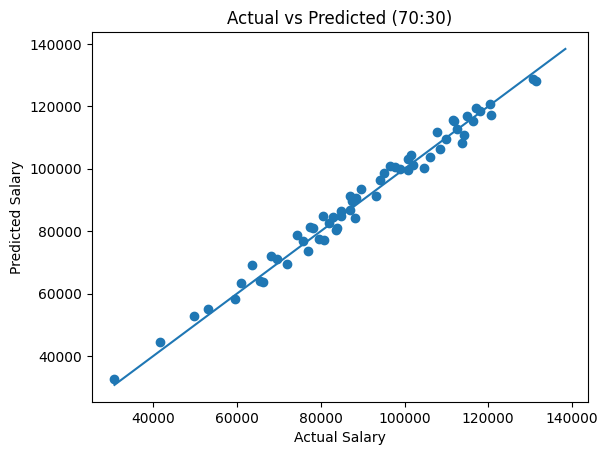

MAE: 2555.4715086261226
MSE: 8324508.338408826
R2 Score: 0.98226101262323

--- Train-Test Split 60:40 ---
Intercept: 1583.730187068766
Coefficients:
years_experience: 3942.0613622052188
education_level: 8028.184136557073
projects_completed: 1473.1896013719263
performance_score: 1757.211990120633
working_hours_per_week: 214.32640115570257
certifications: 3032.8927006239055


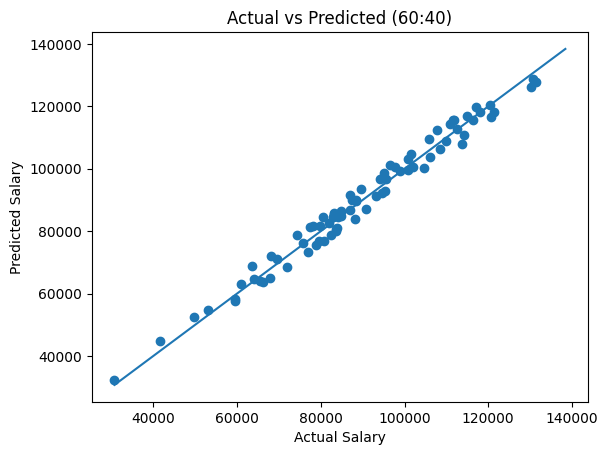

MAE: 2570.198777067447
MSE: 8439182.632205393
R2 Score: 0.9802130720259865

--- Train-Test Split 80:20 ---
Intercept: 2462.6569971895515
Coefficients:
years_experience: 3950.040918887571
education_level: 7752.788727573789
projects_completed: 1436.9440958949547
performance_score: 1892.9508864377403
working_hours_per_week: 189.0095462076979
certifications: 3091.327909166616


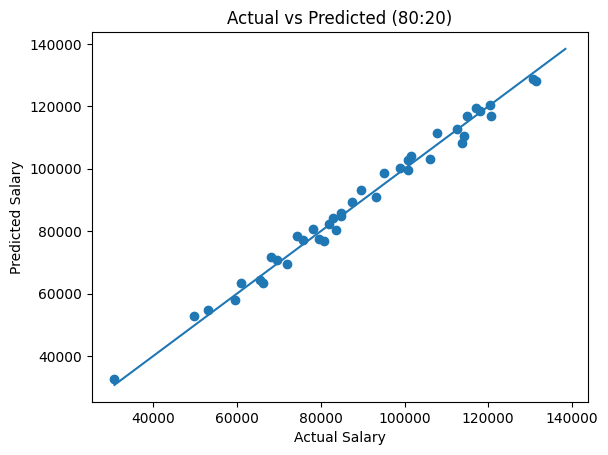

MAE: 2253.6531293581006
MSE: 6633638.78685991
R2 Score: 0.9877974719095176


In [13]:
# -------------------------------
# ii. Different Splits
# -------------------------------
model_70 = train_and_evaluate(0.3)
model_60 = train_and_evaluate(0.4)
model_80 = train_and_evaluate(0.2)

In [15]:
# vi. Predict New Data

user_values = []
for col in X.columns:
    val = float(input(f"Enter {col}: "))
    user_values.append(val)

# Convert to DataFrame with column names
user_df = pd.DataFrame([user_values], columns=X.columns)

prediction = model_80.predict(user_df)

print("Predicted Salary:", prediction[0])

Enter years_experience:  3
Enter education_level:  3
Enter projects_completed:  6
Enter performance_score:  8
Enter working_hours_per_week:  38
Enter certifications:  5


Predicted Salary: 83975.41990517089
